# Question 2
What factors go into making an asteroid potentially hazardous or not?

First we sort the data by `miss_distance_km` to find the NEOs that are closest to Earth. First up is a histogram showing `estimated_diameter_max_km`, which is the upper bound for the diamater of the object. We can see that most of them are less than 0.2 km (200 m) in diameter.

Number of asteroids marked as potentially hazardous:
0

First 10 rows of near misses:
   id neo_reference_id         name                                                     nasa_jpl_url  absolute_magnitude_h  estimated_diameter_min_km  estimated_diameter_max_km  is_potentially_hazardous_asteroid close_approach_date close_approach_date_full  relative_velocity_kph  miss_distance_km orbiting_body  is_sentry_object          ingested_at  kinetic_energy_proxy  miss_distance_ld
0  49         54347996   (2023 DZ2)  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996                24.280                   0.037030                   0.082802                                  0          2026-04-04        2026-Apr-04 02:04           26061.586230      1.012422e+06         Earth                 0  2026-04-03 23:48:04          3.855863e+05          2.633771
1  31          3560131   (2011 FT9)   https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3560131                26.200          

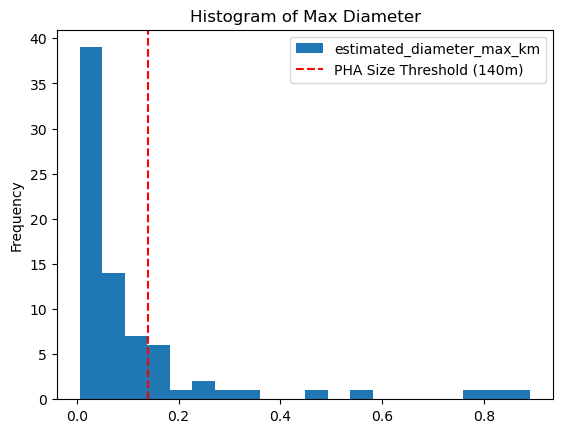

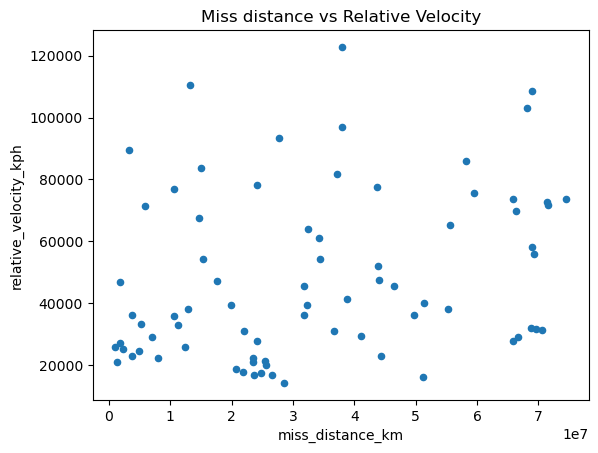

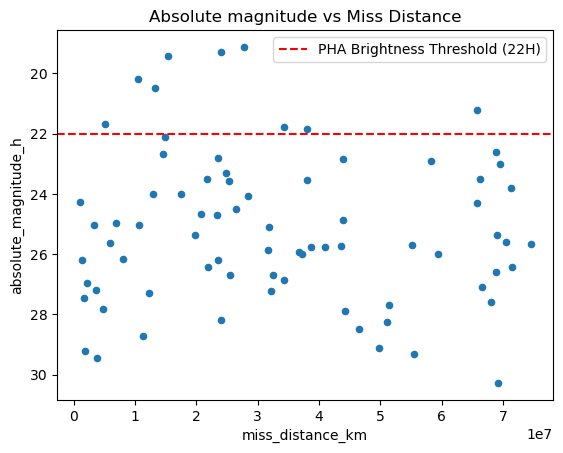

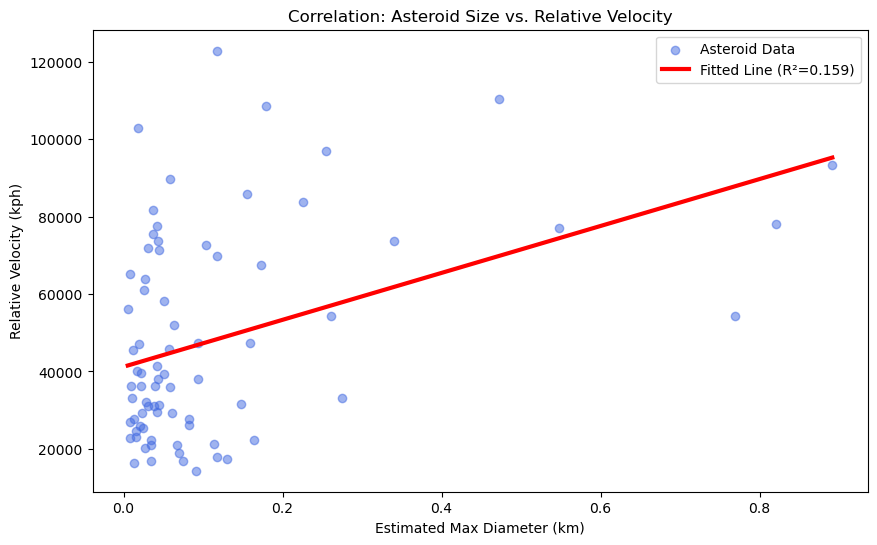

In [5]:
%run ./main.ipynb

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# 1. DATA CALCULATIONS (Do these first so they are ready for plotting)
df_clean['kinetic_energy_proxy'] = (df_clean['estimated_diameter_max_km']**3) * (df_clean['relative_velocity_kph']**2)
df_clean['miss_distance_ld'] = df_clean['miss_distance_km'] / 384400

# 2. PRINT STATS
print("Number of asteroids marked as potentially hazardous:")
df_hazardous = df_clean.query("is_potentially_hazardous_asteroid != 0")
print(df_hazardous.size)

df_near_miss = df_clean.sort_values(by="miss_distance_km")
print("\nFirst 10 rows of near misses:")
print(df_near_miss.head(10).to_string())

print("\nTop 5 Asteroids by Kinetic Energy Potential:")
print(df_clean.sort_values(by='kinetic_energy_proxy', ascending=False)[['name', 'kinetic_energy_proxy']].head())

print(f"\nThe closest asteroid missed by {df_clean['miss_distance_ld'].min():.2f} Lunar Distances.")

# 3. VISUALIZATIONS
# Histogram with Threshold
ax1 = df_near_miss.plot.hist(column="estimated_diameter_max_km", bins=20, title="Histogram of Max Diameter")
ax1.axvline(x=0.14, color='red', linestyle='--', label='PHA Size Threshold (140m)')
ax1.legend()

# Scatter 1: Velocity vs Distance
df_near_miss.plot.scatter(title="Miss distance vs Relative Velocity", y="relative_velocity_kph", x="miss_distance_km")

# Scatter 2: Brightness vs Distance with Threshold
ax2 = df_near_miss.plot.scatter(title="Absolute magnitude vs Miss Distance", x="miss_distance_km", y="absolute_magnitude_h")
ax2.axhline(y=22.0, color='red', linestyle='--', label='PHA Brightness Threshold (22H)')
ax2.invert_yaxis() # Magnitude is an inverse scale (smaller is brighter/bigger)
ax2.legend()

# 4. LINEAR REGRESSION SECTION
diam = np.array(df_clean["estimated_diameter_max_km"])
rv = np.array(df_clean["relative_velocity_kph"])

mask = ~np.isnan(diam) & ~np.isnan(rv)
clean_diam = diam[mask]
clean_rv = rv[mask]

slope, intercept, r_value, p_value, std_err = stats.linregress(clean_diam, clean_rv)

plt.figure(figsize=(10, 6))
plt.scatter(clean_diam, clean_rv, alpha=0.5, label='Asteroid Data', color='royalblue')
x_line = np.array([clean_diam.min(), clean_diam.max()])
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='red', linewidth=3, label=f'Fitted Line (R²={r_value**2:.3f})')
plt.title("Correlation: Asteroid Size vs. Relative Velocity")
plt.xlabel("Estimated Max Diameter (km)")
plt.ylabel("Relative Velocity (kph)")
plt.legend()
plt.show()



## Definitions and Measurements
### 1. Key Metrics & Calculated Fields

| Metric | Definition | Unit / Calculation |
| :--- | :--- | :--- |
| **Estimated Diameter Max** | The upper bound of an asteroid's size based on its brightness and reflectivity. | Kilometers (km) |
| **Relative Velocity** | The speed of the asteroid relative to Earth at its closest approach. | Kilometers per hour (kph) |
| **Miss Distance** | The distance between the asteroid and Earth at the point of closest approach. | Kilometers (km) |
| **Absolute Magnitude ($H$)** | The intrinsic brightness of an asteroid. Smaller numbers indicate larger, brighter objects. | Magnitude ($H$) |
| **Lunar Distance (LD)** | A measurement used to visualize proximity relative to the Moon. | $1 \text{ LD} \approx 384,400\text{ km}$ |
| **Kinetic Energy Proxy** | A calculated value representing the "impact force" potential of an asteroid. | $(\text{Diameter}^3) \times (\text{Velocity}^2)$ |

---

### 2. Scientific Thresholds for PHA Classification

NASA and the Minor Planet Center classify an asteroid as a **Potentially Hazardous Asteroid (PHA)** if it meets two specific criteria represented in our visualizations:

* **Size Threshold ($0.14\text{ km}$):** Asteroids larger than **140 meters** are considered large enough to cause significant regional damage. In our histogram, this is marked by the red dashed line at **0.14**.
* **Brightness Threshold ($22.0\text{ H}$):** Since actual size is hard to measure, an Absolute Magnitude of **22.0** or brighter (lower) is used as the official proxy for the 140m size limit.
* **Proximity Threshold ($0.05\text{ AU}$):** While not a single point on our "near miss" plots, an asteroid must have a Minimum Orbit Intersection Distance (MOID) of roughly **7.5 million km** to be labeled a PHA.

---

### 3. Statistical Analysis Terms

In our **Linear Regression** section, we use three primary indicators to test the relationship between asteroid size and speed:

1.  **Regression Line (Fitted Line):** A mathematical trendline ($y = mx + b$) that shows if velocity tends to increase or decrease as asteroids get larger.
2.  **R-squared ($R^2$):** A value between 0 and 1 that tells us how well "Size" explains "Velocity."
    * *Example:* An $R^2$ of 0.02 means only 2% of the velocity is determined by size; the rest is determined by the asteroid's unique orbit.
3.  **P-value:** A measure of statistical significance.
    * **$P < 0.05$:** The relationship is likely real and not due to chance.
    * **$P > 0.05$:** No reliable correlation exists between the two factors in this dataset.

---

### 4. Data Logic & Cleaning

* **NaN Masking:** To ensure mathematical accuracy, the code automatically filters out "NaN" (Not a Number) entries. This prevents incomplete data from skewing the averages or breaking the linear regression model.
* **Inverse Magnitude Scale:** In the "Brightness vs. Distance" scatter plot, the Y-axis is inverted. This ensures that **larger/brighter** asteroids appear at the top of the graph, making it more intuitive to read.

## Heatmap of Findings

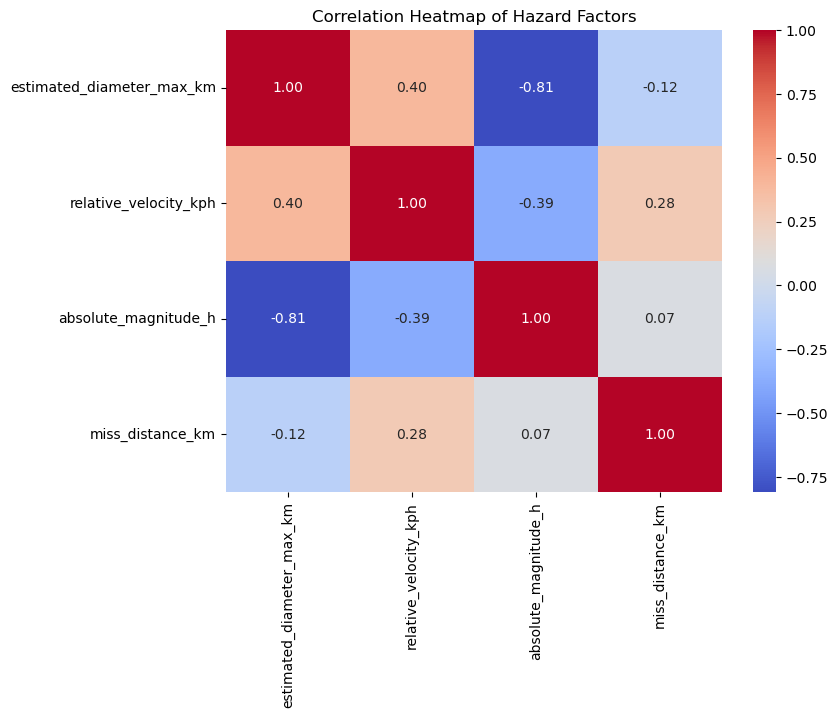

In [6]:
#Correction Matrix
import seaborn as sns

# Select the numeric columns relevant to Question 2
cols_to_check = ['estimated_diameter_max_km', 'relative_velocity_kph', 'absolute_magnitude_h', 'miss_distance_km']
correlation_matrix = df_clean[cols_to_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Hazard Factors")
plt.show()

## Findings Analysis Writeup
 